In [1]:
from collections import Counter
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import pandas as pd
import time
import numpy as np
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

DataSet, Labels = fetch_openml('mnist_784', version=1, return_X_y=True)
print('Overall # of samples is', Labels.shape[0])
print('Size of the features is:', DataSet.shape)

Overall # of samples is 70000
Size of the features is: (70000, 784)


In [2]:
X = DataSet.to_numpy()
y = Labels.to_numpy()

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [4]:
X_train[2]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  16,
       191, 255,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [5]:
y_train[2]

'1'

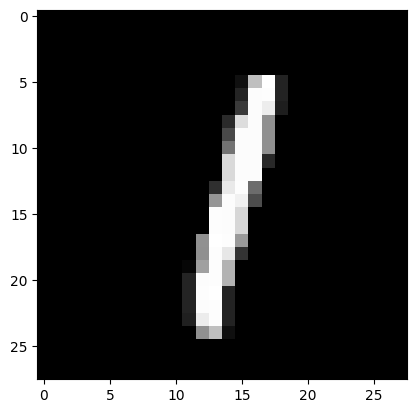

In [6]:
plt.imshow(X_train[2].reshape(28,28), cmap='gray')
plt.show()

In [7]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=6)

In [8]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [9]:
y_pred = knn.predict(X_test)

In [10]:
y_pred

array(['0', '4', '1', ..., '5', '9', '2'], dtype=object)

In [11]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9679428571428571


Veamos con ejemplos unitarios

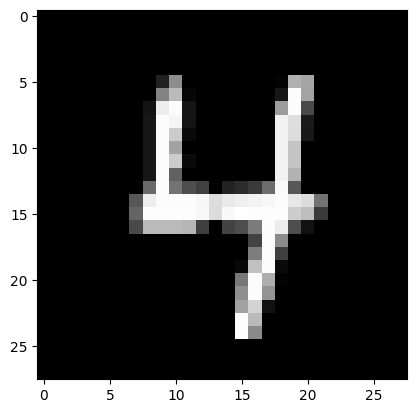

In [15]:
plt.imshow(X_test[1].reshape(28,28), cmap='gray')
plt.show()

In [16]:
knn.predict(X_test[1].reshape(1,-1))

array(['4'], dtype=object)

In [ ]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = DataSet.to_numpy()
y = Labels.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
results={}
for n_neig in range (1,10):
    knn = KNeighborsClassifier(n_neighbors=n_neig)
    knn.fit(X_train, y_train)
    acc=[]
    for n in range(0,10):
        #try:
            X_test_f=X_test[np.where(y_test==str(n))]
            y_test_f=y_test[np.where(y_test==str(n))]
            y_pred = knn.predict(X_test_f)
            acc=acc+[metrics.accuracy_score(y_test_f, y_pred)]
            print("Accuracy caso " + str(n) + " :",metrics.accuracy_score(y_test_f, y_pred))

    results[str(n_neig)]=acc
        #except: 
        #    pass

Accuracy caso 0 : 0.9912536443148688
Accuracy caso 1 : 0.9979705733130391
Accuracy caso 2 : 0.9680851063829787
Accuracy caso 3 : 0.9665343165059558
Accuracy caso 4 : 0.9683770883054893
Accuracy caso 5 : 0.9579409918392969
Accuracy caso 6 : 0.9853801169590644
Accuracy caso 7 : 0.9722373434948285
Accuracy caso 8 : 0.9357851722124927
Accuracy caso 9 : 0.9602534562211982
Accuracy caso 0 : 0.9947521865889213
Accuracy caso 1 : 0.9984779299847792
Accuracy caso 2 : 0.9697648376259799
Accuracy caso 3 : 0.9722064662507091
Accuracy caso 4 : 0.9803102625298329
Accuracy caso 5 : 0.9529190207156308
Accuracy caso 6 : 0.9771929824561404
Accuracy caso 7 : 0.9662493195427327
Accuracy caso 8 : 0.9083479276123759
Accuracy caso 9 : 0.9274193548387096
Accuracy caso 0 : 0.9918367346938776
Accuracy caso 1 : 0.9969558599695586
Accuracy caso 2 : 0.9703247480403135
Accuracy caso 3 : 0.9653998865570051
Accuracy caso 4 : 0.9671837708830548
Accuracy caso 5 : 0.96045197740113
Accuracy caso 6 : 0.9836257309941521
Acc

In [39]:
df

,1,2,3,4,5,6,7,8,9
0,0.991254,0.994752,0.991837,0.994169,0.993003,0.993003,0.991837,0.991837,0.992420
1,0.997971,0.998478,0.996956,0.997463,0.997463,0.997463,0.997971,0.997463,0.996449
2,0.968085,0.969765,0.970325,0.969205,0.963046,0.960246,0.959686,0.960246,0.956887
3,0.966534,0.972206,0.965400,0.964833,0.961997,0.964265,0.960862,0.963698,0.960295
4,0.968377,0.980310,0.967184,0.972554,0.968377,0.972554,0.967184,0.968974,0.961217
5,0.957941,0.952919,0.960452,0.956685,0.960452,0.960452,0.959824,0.957941,0.959824
6,0.985380,0.977193,0.983626,0.982456,0.983626,0.983626,0.984211,0.984211,0.984795
7,0.972237,0.966249,0.970060,0.970604,0.970060,0.967882,0.967338,0.967882,0.967338
8,0.935785,0.908348,0.934034,0.921191,0.928780,0.925277,0.929947,0.921775,0.926445
9,0.960253,0.927419,0.962558,0.947581,0.961982,0.950461,0.960829,0.955069,0.957949


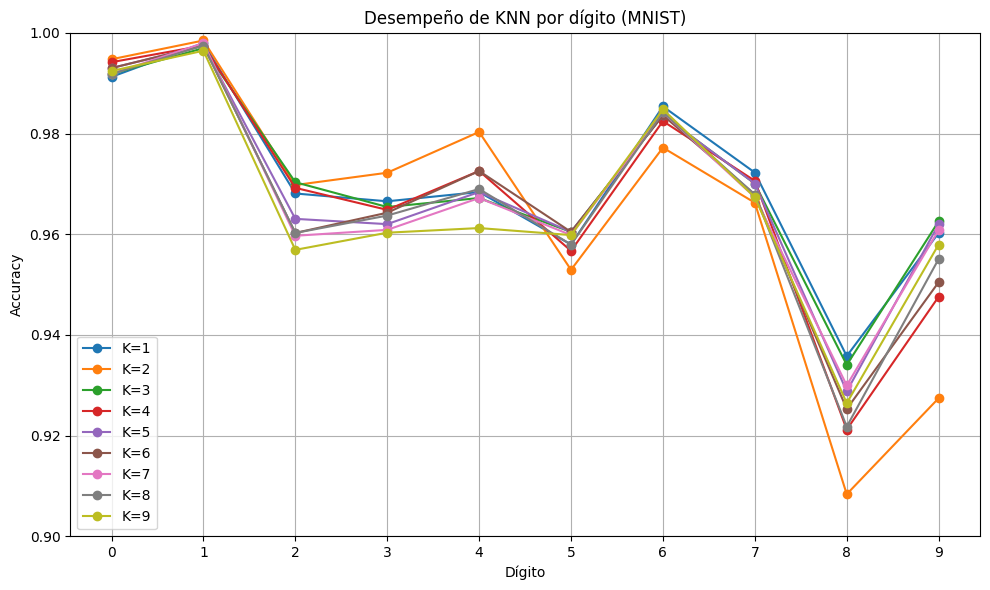

In [40]:
# Convertir a DataFrame
df = pd.DataFrame(results)
columnas=[]
for i in range(1,10):
    columnas=columnas+['K='+str(i)]
df.columns =columnas
df['Dígito'] = list(range(10))

# Graficar
plt.figure(figsize=(10, 6))
for i in range(1,10):
    plt.plot(df['Dígito'], df['K='+str(i)], marker='o', label='K='+str(i))
  
plt.title('Desempeño de KNN por dígito (MNIST)')
plt.xlabel('Dígito')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)
plt.grid(True)
plt.legend()
plt.xticks(range(10))
plt.tight_layout()
plt.show()

In [43]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = DataSet.to_numpy()
y = Labels.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
results={}

acc=[]
for n_neig in range (1,10):
    knn = KNeighborsClassifier(n_neighbors=n_neig)
    knn.fit(X_train, y_train)
  

    y_pred = knn.predict(X_test)
    acc=acc+[metrics.accuracy_score(y_test, y_pred)]
    print("Accuracy caso " + str(n_neig) + " :",metrics.accuracy_score(y_test, y_pred))

        #except: 
        #    pass

Accuracy caso 1 : 0.9708571428571429
Accuracy caso 2 : 0.9653142857142857
Accuracy caso 3 : 0.9706857142857143
Accuracy caso 4 : 0.9681714285714286
Accuracy caso 5 : 0.9693142857142857
Accuracy caso 6 : 0.9679428571428571
Accuracy caso 7 : 0.9684
Accuracy caso 8 : 0.9673714285714285
Accuracy caso 9 : 0.9668
